In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
# Load the cleaned environmental dataset

data_folder = "/content/drive/MyDrive/MMA3001_Building_Sensor_Project/data"

env = pd.read_csv(data_folder + "/env_clean.csv")

print("Dataset size:", env.shape)
print("\nColumns:")
print(env.columns.tolist())

env.head()

Dataset size: (179447, 13)

Columns:
['sensorid', 'createdate', 'Battery', 'Carbon dioxide', 'Humidity', 'Formaldehyde', 'Pressure', 'Temperature', 'Light Volatile Organic Compounds', 'Particulate matter 1', 'Particulate matter 4', 'Particulate matter 2.5', 'Particulate matter 10']


,sensorid,createdate,Battery,Carbon dioxide,Humidity,Formaldehyde,Pressure,Temperature,Light Volatile Organic Compounds,Particulate matter 1,Particulate matter 4,Particulate matter 2.5,Particulate matter 10
0,6012002000241,2024-02-28 16:11:58.210358+00:00,4.1875,603.0,66.0,6.0,1011.0,23.8,14.0,8.0,9.0,9.0,9.0
1,6012002000241,2024-02-29 06:09:08.833822+00:00,4.1875,603.0,66.0,6.0,1011.0,23.8,14.0,8.0,9.0,9.0,9.0
2,6012002000326,2024-02-29 06:09:12.444245+00:00,4.1875,525.0,68.0,5.0,1012.0,23.8,7.0,6.0,6.0,6.0,6.0
3,6012002000777,2024-02-29 06:10:24.443407+00:00,4.1562,425.0,51.0,1.0,1015.0,18.8,71.0,1.0,3.0,3.0,4.0
4,6012002000869,2024-02-29 06:11:11.348578+00:00,4.1250,465.0,56.0,17.0,1010.0,24.3,0.0,2.0,2.0,2.0,2.0


In [3]:
# Select one environmental sensor
sensor_data = env[
    env["sensorid"] == 6012002000241
].copy()

# Convert timestamps to Melbourne local time
sensor_data["createdate"] = pd.to_datetime(
    sensor_data["createdate"],
    utc=True
).dt.tz_convert("Australia/Melbourne")

# Extract time-based variables
sensor_data["hour"] = (
    sensor_data["createdate"].dt.hour
    + sensor_data["createdate"].dt.minute / 60
)

sensor_data["day_of_week"] = (
    sensor_data["createdate"].dt.dayofweek
)

# Sort chronologically
sensor_data = sensor_data.sort_values("createdate")

# Select the variables needed for modelling
model_data = sensor_data[
    [
        "createdate",
        "hour",
        "day_of_week",
        "Temperature",
        "Humidity",
        "Carbon dioxide"
    ]
].copy()

print("Modelling dataset size:", model_data.shape)

model_data.head()

Modelling dataset size: (58908, 6)


,createdate,hour,day_of_week,Temperature,Humidity,Carbon dioxide
0,2024-02-29 03:11:58.210358+11:00,3.183333,3,23.8,66.0,603.0
1,2024-02-29 17:09:08.833822+11:00,17.150000,3,23.8,66.0,603.0
5,2024-02-29 17:22:34.093728+11:00,17.366667,3,23.8,66.0,603.0
9,2024-02-29 17:35:57.985057+11:00,17.583333,3,23.8,66.0,603.0
13,2024-02-29 17:49:25.518180+11:00,17.816667,3,23.8,66.0,603.0


In [4]:
# Check for missing values
print("Missing values:")
print(model_data.isnull().sum())

# Check for duplicate timestamps
print("\nDuplicate timestamps:")
print(model_data["createdate"].duplicated().sum())

# Check the date range
print("\nFirst reading:")
print(model_data["createdate"].min())

print("\nLast reading:")
print(model_data["createdate"].max())

# Check the range of CO2 measurements
print("\nCO2 statistics:")
print(model_data["Carbon dioxide"].describe())

Missing values:
createdate        0
hour              0
day_of_week       0
Temperature       0
Humidity          0
Carbon dioxide    0
dtype: int64

Duplicate timestamps:
0

First reading:
2024-02-29 03:11:58.210358+11:00

Last reading:
2026-04-22 23:20:32.020253+10:00

CO2 statistics:
count    58908.000000
mean       524.703402
std         78.000098
min        447.000000
25%        447.000000
50%        447.000000
75%        603.000000
max        603.000000
Name: Carbon dioxide, dtype: float64


Most common CO2 readings:
Carbon dioxide
447.0    29566
603.0    29342
Name: count, dtype: int64


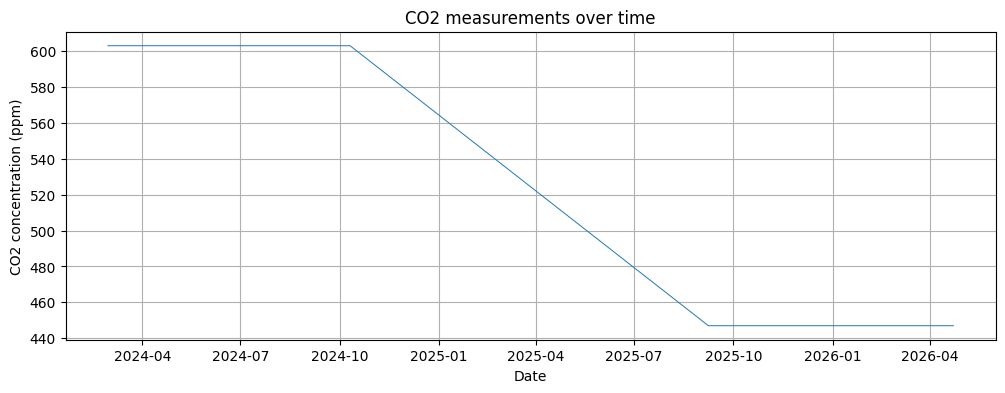

In [5]:
# Check how frequently each CO2 value occurs
print("Most common CO2 readings:")
print(model_data["Carbon dioxide"].value_counts().head(10))

# Check how much CO2 changes over time
plt.figure(figsize=(12, 4))

plt.plot(
    model_data["createdate"],
    model_data["Carbon dioxide"],
    linewidth=0.7
)

plt.xlabel("Date")
plt.ylabel("CO2 concentration (ppm)")
plt.title("CO2 measurements over time")
plt.grid(True)
plt.show()

In [6]:
# Compare CO2 variation across all five sensors

sensor_quality = env.groupby("sensorid")["Carbon dioxide"].agg(
    ["count", "nunique", "min", "max", "std"]
)

sensor_quality = sensor_quality.rename(columns={
    "count": "Number of readings",
    "nunique": "Unique CO2 values",
    "min": "Minimum CO2",
    "max": "Maximum CO2",
    "std": "Standard deviation"
})

print(sensor_quality.round(2))

               Number of readings  Unique CO2 values  Minimum CO2  \
sensorid                                                            
6012002000227               21363                  1        666.0   
6012002000241               58908                  2        447.0   
6012002000326               58909                245        400.0   
6012002000777               10926                  1        425.0   
6012002000869               29341                222        403.0   

               Maximum CO2  Standard deviation  
sensorid                                        
6012002000227        666.0                0.00  
6012002000241        603.0               78.00  
6012002000326       1387.0               45.74  
6012002000777        425.0                0.00  
6012002000869        646.0               35.54  


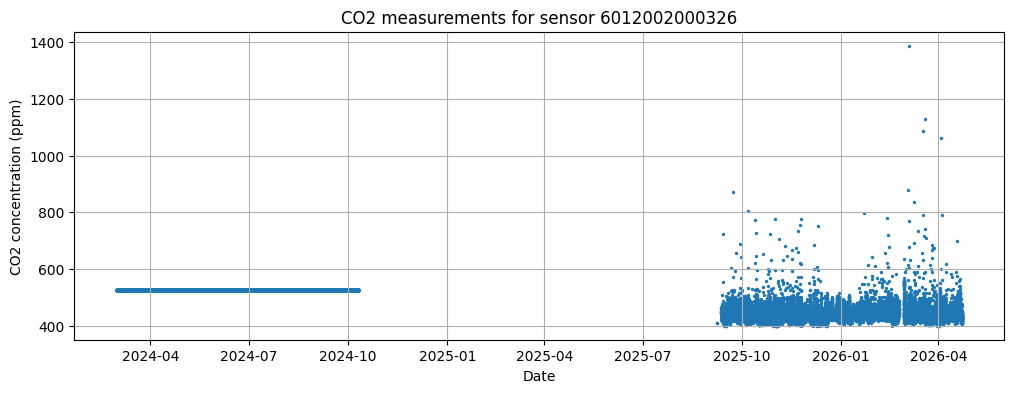

Most common CO2 readings:
Carbon dioxide
525.0    29348
433.0      796
436.0      779
437.0      777
432.0      762
431.0      761
430.0      751
434.0      750
438.0      731
429.0      725
Name: count, dtype: int64


In [7]:
# Investigate sensor 6012002000326

new_sensor = env[
    env["sensorid"] == 6012002000326
].copy()

# Convert timestamps
new_sensor["createdate"] = pd.to_datetime(
    new_sensor["createdate"],
    utc=True
).dt.tz_convert("Australia/Melbourne")

# Sort by date
new_sensor = new_sensor.sort_values("createdate")

# Plot CO2 readings over time
plt.figure(figsize=(12, 4))

plt.scatter(
    new_sensor["createdate"],
    new_sensor["Carbon dioxide"],
    s=2
)

plt.xlabel("Date")
plt.ylabel("CO2 concentration (ppm)")
plt.title("CO2 measurements for sensor 6012002000326")
plt.grid(True)
plt.show()

# Check the most common readings
print("Most common CO2 readings:")
print(new_sensor["Carbon dioxide"].value_counts().head(10))

In [8]:
# Select the period with varying CO2 measurements
usable_data = new_sensor[
    new_sensor["createdate"] >= "2025-09-01"
].copy()

print("Number of readings:", len(usable_data))

print("\nCO2 statistics:")
print(usable_data["Carbon dioxide"].describe())

print("\nUnique CO2 values:")
print(usable_data["Carbon dioxide"].nunique())

# Check the number of readings each month
usable_data["month"] = (
    usable_data["createdate"].dt.to_period("M")
)

print("\nReadings per month:")
print(usable_data.groupby("month")["Carbon dioxide"].agg(
    ["count", "nunique", "std"]
).round(2))

Number of readings: 29567

CO2 statistics:
count    29567.000000
mean       440.940102
std         25.469763
min        400.000000
25%        427.000000
50%        437.000000
75%        449.000000
max       1387.000000
Name: Carbon dioxide, dtype: float64

Unique CO2 values:
245

Readings per month:
         count  nunique    std
month                         
2025-09   2580      120  22.84
2025-10   4189      142  24.78
2025-11   4063      146  24.00
2025-12   4198      129  20.97
2026-01   4199      122  18.05
2026-02   3158      150  24.09
2026-03   4199      167  35.70
2026-04   2981      144  27.07


/tmp/ipykernel_576/290815600.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usable_data["createdate"].dt.to_period("M")


In [9]:
# Prepare the final modelling dataset

model_data = usable_data.copy()

# Create numerical time variables
model_data["hour"] = (
    model_data["createdate"].dt.hour
    + model_data["createdate"].dt.minute / 60
)

model_data["day_of_week"] = (
    model_data["createdate"].dt.dayofweek
)

# Select the required columns
model_data = model_data[
    [
        "createdate",
        "hour",
        "day_of_week",
        "Temperature",
        "Humidity",
        "Carbon dioxide"
    ]
].copy()

# Sort chronologically
model_data = model_data.sort_values(
    "createdate"
).reset_index(drop=True)

# Check the final dataset
print("Final dataset size:", model_data.shape)

print("\nMissing values:")
print(model_data.isnull().sum())

model_data.head()

Final dataset size: (29567, 6)

Missing values:
createdate        0
hour              0
day_of_week       0
Temperature       0
Humidity          0
Carbon dioxide    0
dtype: int64


,createdate,hour,day_of_week,Temperature,Humidity,Carbon dioxide
0,2025-09-07 20:14:06.205114+10:00,20.233333,6,19.0,60.0,410.0
1,2025-09-07 20:14:31.070348+10:00,20.233333,6,19.0,60.0,410.0
2,2025-09-11 22:43:08.382587+10:00,22.716667,3,16.0,58.0,461.0
3,2025-09-11 22:53:48.294737+10:00,22.883333,3,16.3,57.0,448.0
4,2025-09-11 23:04:26.805310+10:00,23.066667,3,16.3,57.0,463.0


In [10]:
# Split the dataset chronologically

n = len(model_data)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

train_data = model_data.iloc[:train_end].copy()
val_data = model_data.iloc[train_end:val_end].copy()
test_data = model_data.iloc[val_end:].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(val_data))
print("Testing rows:", len(test_data))

print("\nTraining period:")
print(train_data["createdate"].min())
print(train_data["createdate"].max())

print("\nValidation period:")
print(val_data["createdate"].min())
print(val_data["createdate"].max())

print("\nTesting period:")
print(test_data["createdate"].min())
print(test_data["createdate"].max())

Training rows: 17740
Validation rows: 5913
Testing rows: 5914

Training period:
2025-09-07 20:14:06.205114+10:00
2026-01-21 00:02:48.845189+11:00

Validation period:
2026-01-21 00:13:26.688660+11:00
2026-03-10 08:14:39.614076+11:00

Testing period:
2026-03-10 08:25:22.065217+11:00
2026-04-22 23:20:33.199878+10:00


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the average CO2 concentration using training data only
baseline_mean = train_data["Carbon dioxide"].mean()

# Predict that average for every validation observation
baseline_predictions = np.full(
    len(val_data),
    baseline_mean
)

# Actual validation measurements
actual_values = val_data["Carbon dioxide"]

# Calculate prediction errors
baseline_mae = mean_absolute_error(
    actual_values,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(actual_values, baseline_predictions)
)

baseline_r2 = r2_score(
    actual_values,
    baseline_predictions
)

print("Baseline mean CO2:", round(baseline_mean, 2), "ppm")
print("Baseline MAE:", round(baseline_mae, 2), "ppm")
print("Baseline RMSE:", round(baseline_rmse, 2), "ppm")
print("Baseline R²:", round(baseline_r2, 3))

Baseline mean CO2: 438.39 ppm
Baseline MAE: 15.78 ppm
Baseline RMSE: 29.62 ppm
Baseline R²: -0.088


In [12]:
from sklearn.tree import DecisionTreeRegressor

# Define the input variables
features = [
    "Temperature",
    "Humidity",
    "hour",
    "day_of_week"
]

# Prepare training and validation data
X_train = train_data[features]
y_train = train_data["Carbon dioxide"]

X_val = val_data[features]
y_val = val_data["Carbon dioxide"]

# Create and train the decision-tree model
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predict CO2 concentrations
tree_predictions = tree_model.predict(X_val)

# Calculate validation metrics
tree_mae = mean_absolute_error(y_val, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_val, tree_predictions))
tree_r2 = r2_score(y_val, tree_predictions)

print("Decision Tree MAE:", round(tree_mae, 2), "ppm")
print("Decision Tree RMSE:", round(tree_rmse, 2), "ppm")
print("Decision Tree R²:", round(tree_r2, 3))

Decision Tree MAE: 15.76 ppm
Decision Tree RMSE: 29.06 ppm
Decision Tree R²: -0.047


In [13]:
import time

# Test different tree depths
depths = [2, 3, 4, 5, 6, 8, 10, 15, 20]

results = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Measure training time
    start_time = time.perf_counter()

    model.fit(X_train, y_train)

    training_time = time.perf_counter() - start_time

    # Predict validation data
    predictions = model.predict(X_val)

    # Calculate performance
    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    results.append({
        "Tree Depth": depth,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training Time (s)": training_time
    })

# Display results
results_df = pd.DataFrame(results)

print(results_df.round(3))

   Tree Depth     MAE    RMSE     R2  Training Time (s)
0           2  14.545  28.049  0.025              0.023
1           3  15.204  28.546 -0.010              0.055
2           4  15.653  28.877 -0.033              0.036
3           5  15.758  29.060 -0.047              0.047
4           6  15.858  28.942 -0.038              0.067
5           8  16.713  29.494 -0.078              0.083
6          10  18.960  31.724 -0.247              0.042
7          15  22.182  34.985 -0.517              0.094
8          20  22.561  35.527 -0.564              0.102


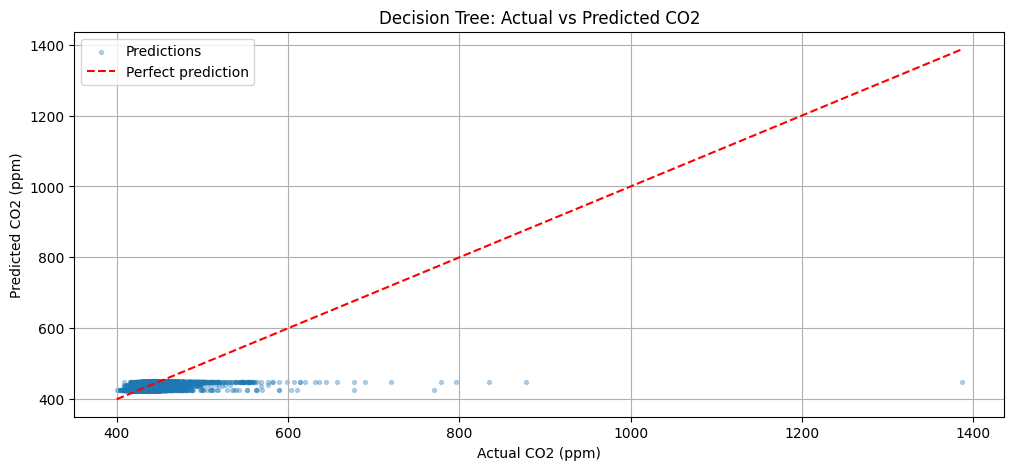

In [14]:
# Train the optimised decision tree
best_tree = DecisionTreeRegressor(
    max_depth=2,
    random_state=42
)

best_tree.fit(X_train, y_train)

# Generate validation predictions
best_predictions = best_tree.predict(X_val)

# Plot actual versus predicted CO2
plt.figure(figsize=(12, 5))

plt.scatter(
    y_val,
    best_predictions,
    alpha=0.3,
    s=8,
    label="Predictions"
)

# Perfect prediction reference line
minimum = min(y_val.min(), best_predictions.min())
maximum = max(y_val.max(), best_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual CO2 (ppm)")
plt.ylabel("Predicted CO2 (ppm)")
plt.title("Decision Tree: Actual vs Predicted CO2")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
import time

# Create the linear regression model
linear_model = LinearRegression()

# Measure training time
start_time = time.perf_counter()

# Train using the same input variables
linear_model.fit(X_train, y_train)

linear_training_time = time.perf_counter() - start_time

# Predict validation CO2 concentrations
linear_predictions = linear_model.predict(X_val)

# Calculate validation metrics
linear_mae = mean_absolute_error(y_val, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_val, linear_predictions)
)

linear_r2 = r2_score(y_val, linear_predictions)

print("Linear Regression MAE:", round(linear_mae, 2), "ppm")
print("Linear Regression RMSE:", round(linear_rmse, 2), "ppm")
print("Linear Regression R²:", round(linear_r2, 3))
print("Training time:", round(linear_training_time, 4), "seconds")

Linear Regression MAE: 16.03 ppm
Linear Regression RMSE: 29.4 ppm
Linear Regression R²: -0.071
Training time: 0.0217 seconds


In [16]:
# Calculate time between consecutive measurements

time_gaps = (
    model_data["createdate"]
    .diff()
    .dt.total_seconds()
    / 60
)

print("Time between readings (minutes):")
print(time_gaps.describe())

print("\nMost common intervals:")
print(time_gaps.round().value_counts().head(10))

Time between readings (minutes):
count    29566.000000
mean        11.062249
std         50.849668
min          0.414421
25%         10.621224
50%         10.626261
75%         10.635005
max       6465.190705
Name: createdate, dtype: float64

Most common intervals:
createdate
11.0    29521
21.0       13
16.0       13
12.0        4
27.0        3
22.0        2
10.0        1
0.0         1
13.0        1
18.0        1
Name: count, dtype: int64


In [17]:
# Create a new forecasting dataset
forecast_data = model_data.copy()

# Six readings ahead is approximately one hour
forecast_data["future_co2"] = (
    forecast_data["Carbon dioxide"].shift(-6)
)

forecast_data["future_time"] = (
    forecast_data["createdate"].shift(-6)
)

# Calculate the actual forecasting interval
forecast_data["forecast_minutes"] = (
    forecast_data["future_time"] -
    forecast_data["createdate"]
).dt.total_seconds() / 60

# Keep forecasts approximately one hour ahead
forecast_data = forecast_data[
    forecast_data["forecast_minutes"].between(55, 75)
].copy()

print("Usable forecasting rows:", len(forecast_data))

print("\nActual forecasting intervals:")
print(forecast_data["forecast_minutes"].describe())

forecast_data[
    ["createdate", "Carbon dioxide", "future_co2", "forecast_minutes"]
].head()

Usable forecasting rows: 29502

Actual forecasting intervals:
count    29502.000000
mean        63.815974
std          0.391409
min         55.674178
25%         63.770727
50%         63.802565
75%         63.829693
max         74.708894
Name: forecast_minutes, dtype: float64


,createdate,Carbon dioxide,future_co2,forecast_minutes
2,2025-09-11 22:43:08.382587+10:00,461.0,445.0,63.903548
3,2025-09-11 22:53:48.294737+10:00,448.0,452.0,63.862594
4,2025-09-11 23:04:26.805310+10:00,463.0,448.0,63.855680
5,2025-09-11 23:15:08.107100+10:00,466.0,446.0,63.801038
6,2025-09-11 23:25:45.866362+10:00,453.0,444.0,63.804590


In [18]:
# Compare one-hour forecasting targets

comparison_data = new_sensor.copy()
comparison_data = comparison_data[
    comparison_data["createdate"] >= "2025-09-01"
].sort_values("createdate").reset_index(drop=True)

targets = ["Carbon dioxide", "Temperature", "Humidity"]

# Find the reading closest to one hour later
current = comparison_data[["createdate"] + targets].copy()
future = comparison_data[["createdate"] + targets].copy()

future = future.rename(columns={
    "createdate": "future_time",
    **{col: "future_" + col for col in targets}
})

current["target_time"] = (
    current["createdate"] + pd.Timedelta(hours=1)
)

comparison = pd.merge_asof(
    current.sort_values("target_time"),
    future.sort_values("future_time"),
    left_on="target_time",
    right_on="future_time",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=10)
)

# Keep only observations with a valid future measurement
comparison = comparison.dropna().copy()

# Split chronologically
comparison = comparison.sort_values("createdate")
split = int(len(comparison) * 0.8)

validation = comparison.iloc[split:].copy()

# Evaluate persistence predictions
results = []

for target in targets:
    actual = validation["future_" + target]
    predicted = validation[target]

    results.append({
        "Target": target,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Target SD": actual.std()
    })

comparison_results = pd.DataFrame(results)

print("Total matched observations:", len(comparison))
print("Validation observations:", len(validation))
print("\nPersistence baseline results:")
print(comparison_results.round(3))

Total matched observations: 29557
Validation observations: 5912

Persistence baseline results:
           Target     MAE    RMSE     R2  Target SD
0  Carbon dioxide  14.109  34.690 -0.348     29.881
1     Temperature   0.468   0.636  0.955      3.012
2        Humidity   1.830   2.619  0.917      9.068


In [19]:
# Predict temperature approximately one hour ahead

features_temp = [
    "Temperature",
    "Humidity",
    "Carbon dioxide"
]

split = int(len(comparison) * 0.8)

train_temp = comparison.iloc[:split]
val_temp = comparison.iloc[split:]

X_train_temp = train_temp[features_temp]
y_train_temp = train_temp["future_Temperature"]

X_val_temp = val_temp[features_temp]
y_val_temp = val_temp["future_Temperature"]

models = {
    "Linear regression": LinearRegression(),
    "Decision tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

temp_results = []

# Include the persistence baseline
temp_results.append({
    "Model": "Persistence",
    "MAE": mean_absolute_error(
        y_val_temp, val_temp["Temperature"]
    ),
    "RMSE": np.sqrt(mean_squared_error(
        y_val_temp, val_temp["Temperature"]
    )),
    "R2": r2_score(
        y_val_temp, val_temp["Temperature"]
    )
})

for name, model in models.items():
    model.fit(X_train_temp, y_train_temp)
    predictions = model.predict(X_val_temp)

    temp_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_val_temp, predictions),
        "RMSE": np.sqrt(mean_squared_error(
            y_val_temp, predictions
        )),
        "R2": r2_score(y_val_temp, predictions)
    })

print(pd.DataFrame(temp_results).round(3))

               Model    MAE   RMSE     R2
0        Persistence  0.468  0.636  0.955
1  Linear regression  0.470  0.635  0.956
2      Decision tree  0.485  0.648  0.954


In [20]:
# Add time-based features to the forecasting dataset
comparison["hour"] = (
    comparison["createdate"].dt.hour
    + comparison["createdate"].dt.minute / 60
)

comparison["day_of_week"] = (
    comparison["createdate"].dt.dayofweek
)

# Chronological split
split = int(len(comparison) * 0.8)

train_temp = comparison.iloc[:split]
val_temp = comparison.iloc[split:]

features_temp = [
    "Temperature",
    "Humidity",
    "Carbon dioxide",
    "hour",
    "day_of_week"
]

X_train_temp = train_temp[features_temp]
y_train_temp = train_temp["future_Temperature"]

X_val_temp = val_temp[features_temp]
y_val_temp = val_temp["future_Temperature"]

models = {
    "Linear regression": LinearRegression(),
    "Decision tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_temp, y_train_temp)
    predictions = model.predict(X_val_temp)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_val_temp, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_val_temp, predictions)),
        "R2": r2_score(y_val_temp, predictions)
    })

print(pd.DataFrame(results).round(3))

               Model    MAE   RMSE     R2
0  Linear regression  0.465  0.631  0.956
1      Decision tree  0.483  0.644  0.954


In [21]:
# Prepare the final temperature forecasting dataset

final_data = comparison.copy()

# Sort chronologically
final_data = final_data.sort_values(
    "createdate"
).reset_index(drop=True)

# Select our input variables
features_final = [
    "Temperature",
    "Humidity",
    "Carbon dioxide",
    "hour",
    "day_of_week"
]

# Define the prediction target
target_final = "future_Temperature"

# Keep only the required columns
final_data = final_data[
    ["createdate", "future_time"]
    + features_final
    + [target_final]
].dropna().copy()

print("Final dataset size:", final_data.shape)

print("\nDate range:")
print(final_data["createdate"].min())
print(final_data["createdate"].max())

print("\nMissing values:")
print(final_data.isnull().sum())

Final dataset size: (29557, 8)

Date range:
2025-09-11 22:43:08.382587+10:00
2026-04-22 22:27:24.931145+10:00

Missing values:
createdate            0
future_time           0
Temperature           0
Humidity              0
Carbon dioxide        0
hour                  0
day_of_week           0
future_Temperature    0
dtype: int64


In [22]:
# Calculate chronological split points
n = len(final_data)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

# Identify the boundary timestamps
validation_start = final_data.iloc[train_end]["createdate"]
test_start = final_data.iloc[val_end]["createdate"]

# Create the three datasets
# Remove observations whose forecast windows cross a boundary

train_final = final_data[
    final_data["future_time"] < validation_start
].copy()

val_final = final_data[
    (final_data["createdate"] >= validation_start)
    & (final_data["future_time"] < test_start)
].copy()

test_final = final_data[
    final_data["createdate"] >= test_start
].copy()

# Display results
for name, dataset in [
    ("Training", train_final),
    ("Validation", val_final),
    ("Testing", test_final)
]:
    print(f"\n{name}: {len(dataset)} observations")
    print("First:", dataset["createdate"].min())
    print("Last:", dataset["createdate"].max())

# Verify that forecasting windows don't overlap
assert train_final["future_time"].max() < val_final["createdate"].min()
assert val_final["future_time"].max() < test_final["createdate"].min()

print("\nBoundary checks passed!")


Training: 17728 observations
First: 2025-09-11 22:43:08.382587+10:00
Last: 2026-01-20 22:16:33.978308+11:00

Validation: 5905 observations
First: 2026-01-20 23:30:56.880955+11:00
Last: 2026-03-10 06:38:59.697445+11:00

Testing: 5912 observations
First: 2026-03-10 07:53:25.219468+11:00
Last: 2026-04-22 22:27:24.931145+10:00

Boundary checks passed!


In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Actual temperature approximately one hour later
y_val_final = val_final["future_Temperature"]

# Persistence prediction: temperature stays unchanged
persistence_predictions = val_final["Temperature"]

# Calculate validation performance
persistence_mae = mean_absolute_error(
    y_val_final, persistence_predictions
)

persistence_rmse = np.sqrt(
    mean_squared_error(y_val_final, persistence_predictions)
)

persistence_r2 = r2_score(
    y_val_final, persistence_predictions
)

print("Persistence MAE:", round(persistence_mae, 3), "°C")
print("Persistence RMSE:", round(persistence_rmse, 3), "°C")
print("Persistence R²:", round(persistence_r2, 3))

Persistence MAE: 0.569 °C
Persistence RMSE: 0.741 °C
Persistence R²: 0.946


In [24]:
from sklearn.linear_model import LinearRegression
import time

# Prepare the input variables
X_train_final = train_final[features_final]
y_train_final = train_final["future_Temperature"]

X_val_final = val_final[features_final]
y_val_final = val_final["future_Temperature"]

# Create the model
linear_final = LinearRegression()

# Measure training time
start_time = time.perf_counter()

# Train the model
linear_final.fit(X_train_final, y_train_final)

linear_time = time.perf_counter() - start_time

# Predict validation temperatures
linear_val_predictions = linear_final.predict(X_val_final)

# Calculate validation performance
linear_final_mae = mean_absolute_error(
    y_val_final, linear_val_predictions
)

linear_final_rmse = np.sqrt(
    mean_squared_error(y_val_final, linear_val_predictions)
)

linear_final_r2 = r2_score(
    y_val_final, linear_val_predictions
)

print("Linear Regression MAE:", round(linear_final_mae, 3), "°C")
print("Linear Regression RMSE:", round(linear_final_rmse, 3), "°C")
print("Linear Regression R²:", round(linear_final_r2, 3))
print("Training time:", round(linear_time, 4), "seconds")

Linear Regression MAE: 0.548 °C
Linear Regression RMSE: 0.741 °C
Linear Regression R²: 0.946
Training time: 0.0076 seconds


In [25]:
from sklearn.tree import DecisionTreeRegressor
import time

depths = [2, 3, 4, 5, 6, 8, 10, 15, 20]

tree_results = []

for depth in depths:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    start_time = time.perf_counter()
    model.fit(X_train_final, y_train_final)
    training_time = time.perf_counter() - start_time

    predictions = model.predict(X_val_final)

    tree_results.append({
        "Depth": depth,
        "MAE": mean_absolute_error(y_val_final, predictions),
        "RMSE": np.sqrt(mean_squared_error(
            y_val_final, predictions
        )),
        "R2": r2_score(y_val_final, predictions),
        "Training Time (s)": training_time
    })

tree_results_df = pd.DataFrame(tree_results)

print(tree_results_df.round(3))

   Depth    MAE   RMSE     R2  Training Time (s)
0      2  1.359  1.740  0.704              0.015
1      3  0.900  1.173  0.866              0.018
2      4  0.648  0.862  0.927              0.023
3      5  0.631  0.825  0.933              0.029
4      6  0.538  0.733  0.948              0.033
5      8  0.468  0.670  0.956              0.043
6     10  0.510  0.755  0.944              0.043
7     15  0.569  0.832  0.932              0.060
8     20  0.575  0.844  0.930              0.065


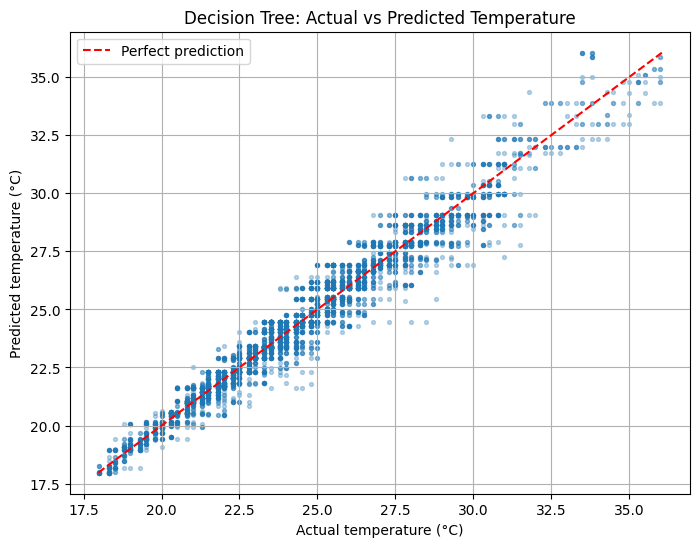

In [26]:
# Train the selected decision tree
best_tree_final = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

best_tree_final.fit(X_train_final, y_train_final)

# Predict validation temperatures
best_tree_predictions = best_tree_final.predict(X_val_final)

# Plot actual versus predicted temperature
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_final,
    best_tree_predictions,
    alpha=0.3,
    s=8
)

minimum = min(y_val_final.min(), best_tree_predictions.min())
maximum = max(y_val_final.max(), best_tree_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual temperature (°C)")
plt.ylabel("Predicted temperature (°C)")
plt.title("Decision Tree: Actual vs Predicted Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Combine training and validation data
train_val = pd.concat(
    [train_final, val_final]
).sort_values("createdate")

X_train_val = train_val[features_final]
y_train_val = train_val["future_Temperature"]

# Prepare untouched test data
X_test = test_final[features_final]
y_test = test_final["future_Temperature"]

# Train final models
final_linear = LinearRegression()
final_linear.fit(X_train_val, y_train_val)

final_tree = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)
final_tree.fit(X_train_val, y_train_val)

# Generate predictions
predictions = {
    "Persistence": test_final["Temperature"],
    "Linear regression": final_linear.predict(X_test),
    "Decision tree": final_tree.predict(X_test)
}

# Calculate final performance
test_results = []

for name, predicted in predictions.items():
    test_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predicted),
        "RMSE": np.sqrt(mean_squared_error(y_test, predicted)),
        "R2": r2_score(y_test, predicted)
    })

test_results_df = pd.DataFrame(test_results)

print(test_results_df.round(3))

               Model    MAE   RMSE     R2
0        Persistence  0.468  0.636  0.955
1  Linear regression  0.465  0.631  0.956
2      Decision tree  0.386  0.560  0.965


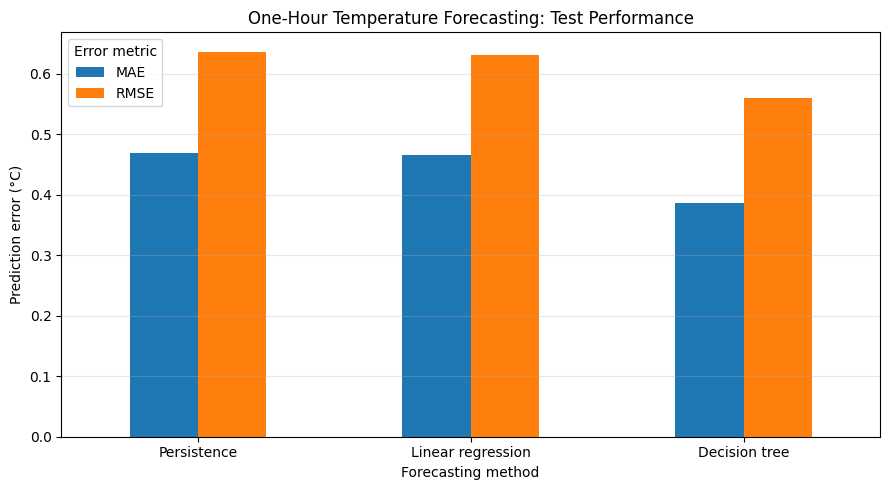

In [28]:
# Compare final test errors

plot_data = test_results_df.set_index("Model")[["MAE", "RMSE"]]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
    rot=0
)

ax.set_title("One-Hour Temperature Forecasting: Test Performance")
ax.set_ylabel("Prediction error (°C)")
ax.set_xlabel("Forecasting method")
ax.legend(title="Error metric")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

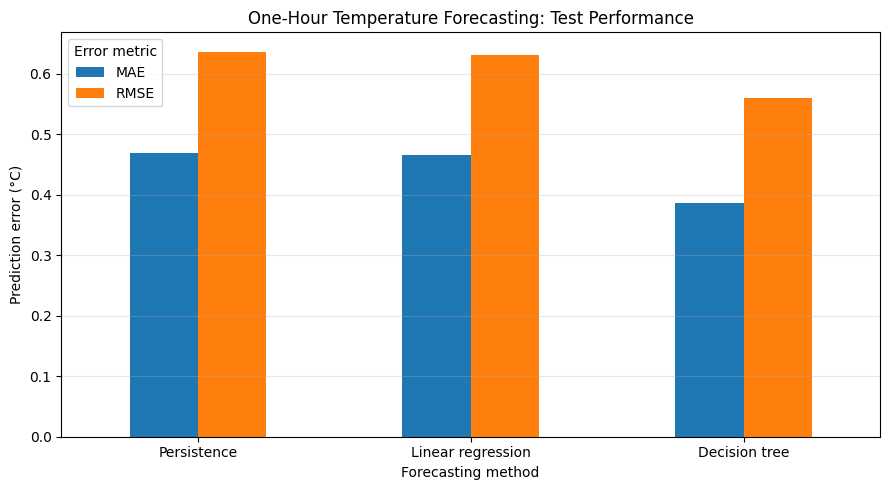

Results saved successfully!


In [29]:
import os

# Create results folder in Google Drive
results_folder = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project/results"
)

os.makedirs(results_folder, exist_ok=True)

# Save final test results
test_results_df.to_csv(
    results_folder + "/final_model_comparison.csv",
    index=False
)

# Recreate and save the graph
ax = test_results_df.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(9, 5),
    rot=0
)

ax.set_title("One-Hour Temperature Forecasting: Test Performance")
ax.set_ylabel("Prediction error (°C)")
ax.set_xlabel("Forecasting method")
ax.legend(title="Error metric")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    results_folder + "/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Results saved successfully!")

In [30]:
# Create reusable model evaluation functions

source_code = '''
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_model(actual, predicted):
    """Calculate regression model performance metrics."""
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted)
    }


def persistence_forecast(current_values):
    """Predict that the future value equals the current value."""
    return np.asarray(current_values)
'''

source_folder = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project/src"
)

os.makedirs(source_folder, exist_ok=True)

with open(source_folder + "/model_utils.py", "w") as file:
    file.write(source_code)

print("Created src/model_utils.py")

Created src/model_utils.py


In [31]:
import sys
sys.path.insert(0, source_folder)

from model_utils import (
    evaluate_model,
    persistence_forecast
)

# Create some simple test data
current = [20, 21, 22, 23]
actual_future = [20.5, 21.5, 22.5, 23.5]

# Test persistence forecasting
predictions = persistence_forecast(current)

# Test evaluation metrics
metrics = evaluate_model(
    actual_future,
    predictions
)

print("Persistence predictions:", predictions)
print("Evaluation results:", metrics)

# Automated checks
assert np.array_equal(
    predictions,
    np.array(current)
)

assert abs(metrics["MAE"] - 0.5) < 0.0001

print("All tests passed!")

Persistence predictions: [20 21 22 23]
Evaluation results: {'MAE': 0.5, 'RMSE': np.float64(0.5), 'R2': 0.8}
All tests passed!


In [32]:
# Create automated tests

test_code = '''
import numpy as np
from src.model_utils import evaluate_model, persistence_forecast


def test_persistence_forecast():
    current = [20, 21, 22, 23]
    predictions = persistence_forecast(current)

    np.testing.assert_array_equal(
        predictions,
        [20, 21, 22, 23]
    )


def test_evaluate_model():
    actual = [20.5, 21.5, 22.5, 23.5]
    predicted = [20, 21, 22, 23]

    results = evaluate_model(actual, predicted)

    assert np.isclose(results["MAE"], 0.5)
    assert np.isclose(results["RMSE"], 0.5)
    assert np.isclose(results["R2"], 0.8)
'''

tests_folder = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project/tests"
)

os.makedirs(tests_folder, exist_ok=True)

with open(tests_folder + "/test_model_utils.py", "w") as file:
    file.write(test_code)

print("Created tests/test_model_utils.py")

Created tests/test_model_utils.py


In [33]:
# Run automated tests
import subprocess

project_folder = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project"
)

result = subprocess.run(
    [
        sys.executable, "-m", "pytest",
        project_folder + "/tests/test_model_utils.py",
        "-v"
    ],
    cwd=project_folder,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/MMA3001_Building_Sensor_Project
plugins: anyio-4.15.1, langsmith-0.12.5, typeguard-4.6.0
collecting ... collected 2 items

tests/test_model_utils.py::test_persistence_forecast PASSED              [ 50%]
tests/test_model_utils.py::test_evaluate_model PASSED                    [100%]

============================== 2 passed in 1.04s ===============================




In [34]:
# Install the documentation tool
%pip install -q pdoc

# Generate HTML documentation
import subprocess

result = subprocess.run(
    [
        sys.executable, "-m", "pdoc",
        project_folder + "/src/model_utils.py",
        "-o", project_folder + "/docs"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode == 0:
    print("Documentation generated successfully!")
else:
    print("Documentation generation failed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 5.3 MB/s eta 0:00:00


Documentation generated successfully!


In [36]:
# Generate predictions from our final models

prediction_results = pd.DataFrame({
    "Date": test_final["createdate"].to_numpy(),
    "Actual Temperature": y_test.to_numpy(),
    "Persistence": test_final["Temperature"].to_numpy(),
    "Linear Regression": final_linear.predict(X_test),
    "Decision Tree": final_tree.predict(X_test)
})

# Save predictions
prediction_results.to_csv(
    results_folder + "/final_test_predictions.csv",
    index=False
)

print("Predictions saved successfully!")
print("Dataset size:", prediction_results.shape)

prediction_results.head()

Predictions saved successfully!
Dataset size: (5912, 5)


,Date,Actual Temperature,Persistence,Linear Regression,Decision Tree
0,2026-03-10 07:53:25.219468+11:00,21.3,21.5,21.427995,21.681818
1,2026-03-10 08:04:02.640800+11:00,21.3,21.3,21.208083,21.364935
2,2026-03-10 08:14:39.614076+11:00,21.3,21.3,21.216852,21.364935
3,2026-03-10 08:25:22.065217+11:00,21.3,21.3,21.220456,21.364935
4,2026-03-10 08:35:59.854030+11:00,21.5,21.0,20.930623,21.364935


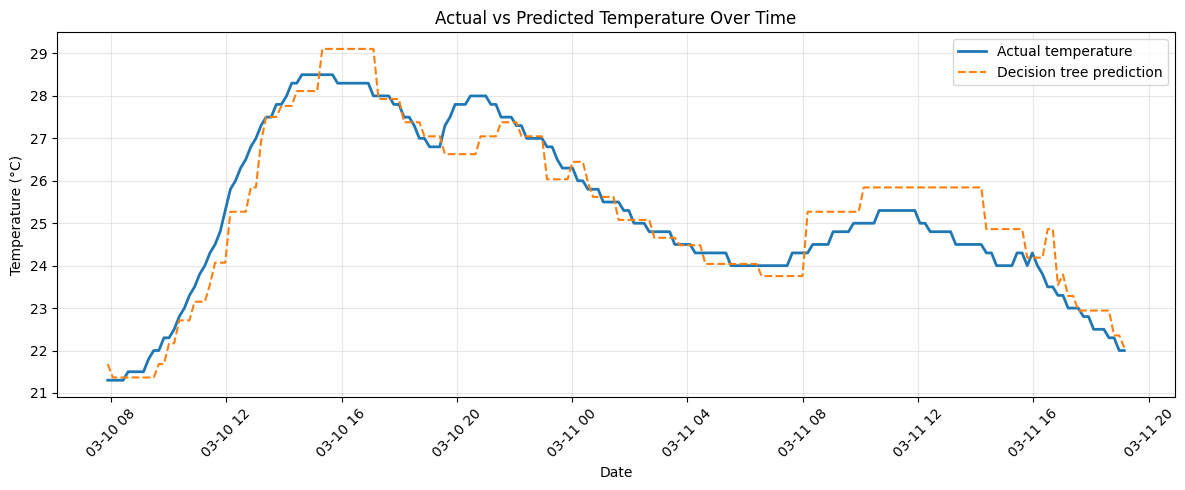

Graph saved successfully!


In [37]:
# Plot actual and predicted temperatures over time
# Display the first 200 test observations for clarity

plot_data = prediction_results.head(200)

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data["Date"],
    plot_data["Actual Temperature"],
    label="Actual temperature",
    linewidth=2
)

plt.plot(
    plot_data["Date"],
    plot_data["Decision Tree"],
    label="Decision tree prediction",
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig(
    results_folder + "/temperature_predictions_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully!")

In [38]:
# Analyse decision-tree prediction errors

error_data = prediction_results.copy()

# Calculate prediction errors
error_data["Error"] = (
    error_data["Decision Tree"]
    - error_data["Actual Temperature"]
)

error_data["Absolute Error"] = (
    error_data["Error"].abs()
)

# Group observations by actual temperature
error_data["Temperature Range"] = pd.cut(
    error_data["Actual Temperature"],
    bins=[-np.inf, 20, 25, 30, np.inf],
    labels=["Below 20°C", "20–25°C", "25–30°C", "Above 30°C"]
)

# Calculate errors for each temperature range
error_summary = error_data.groupby(
    "Temperature Range",
    observed=True
).agg(
    Observations=("Absolute Error", "count"),
    MAE=("Absolute Error", "mean"),
    Mean_Error=("Error", "mean")
)

print(error_summary.round(3))

                   Observations    MAE  Mean_Error
Temperature Range                                 
Below 20°C                 2841  0.318       0.044
20–25°C                    2664  0.424      -0.006
25–30°C                     406  0.606      -0.075
Above 30°C                    1  3.672      -3.672


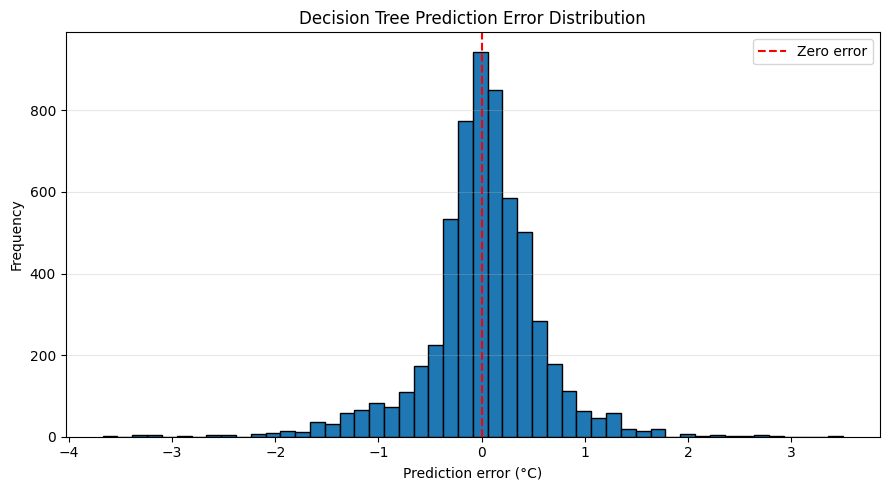

Error analysis saved successfully!


In [39]:
# Save the temperature error analysis
error_summary.to_csv(
    results_folder + "/temperature_error_analysis.csv"
)

# Create an error distribution graph
plt.figure(figsize=(9, 5))

plt.hist(
    error_data["Error"],
    bins=50,
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Zero error"
)

plt.xlabel("Prediction error (°C)")
plt.ylabel("Frequency")
plt.title("Decision Tree Prediction Error Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    results_folder + "/prediction_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Error analysis saved successfully!")

          Feature  Importance
0     Temperature      0.9861
3            hour      0.0128
1        Humidity      0.0006
2  Carbon dioxide      0.0003
4     day_of_week      0.0002


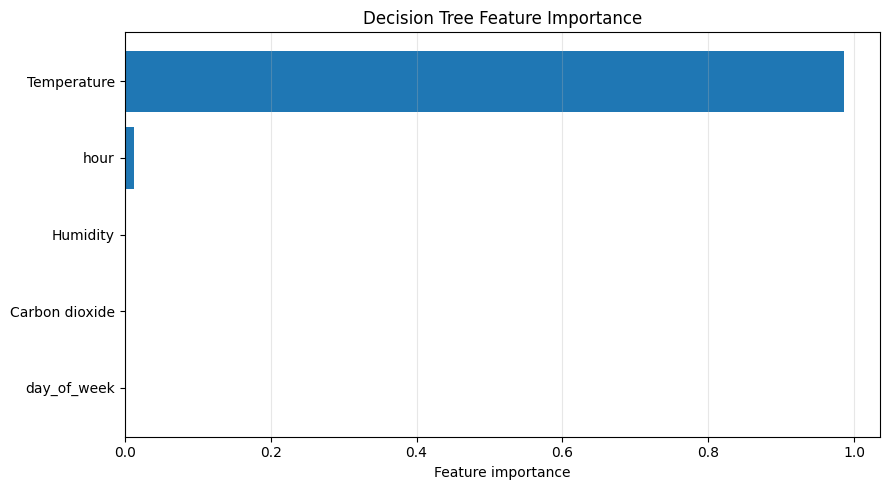

In [40]:
# Calculate feature importance
importance = pd.DataFrame({
    "Feature": features_final,
    "Importance": final_tree.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.round(4))

# Create and save the graph
plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature importance")
plt.title("Decision Tree Feature Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    results_folder + "/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save numerical results
importance.to_csv(
    results_folder + "/feature_importance.csv",
    index=False
)

In [41]:
# Compare a temperature-only model against our full model
from sklearn.tree import DecisionTreeRegressor

# Train a temperature-only decision tree
temperature_only_tree = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

temperature_only_tree.fit(
    train_final[["Temperature"]],
    train_final["future_Temperature"]
)

# Predict using validation data
temp_only_predictions = temperature_only_tree.predict(
    val_final[["Temperature"]]
)

# Compare validation performance
ablation_results = pd.DataFrame([
    {
        "Model": "Temperature only",
        "MAE": mean_absolute_error(
            y_val_final, temp_only_predictions
        ),
        "RMSE": np.sqrt(mean_squared_error(
            y_val_final, temp_only_predictions
        )),
        "R2": r2_score(
            y_val_final, temp_only_predictions
        )
    },
    {
        "Model": "All five variables",
        "MAE": mean_absolute_error(
            y_val_final, best_tree_predictions
        ),
        "RMSE": np.sqrt(mean_squared_error(
            y_val_final, best_tree_predictions
        )),
        "R2": r2_score(
            y_val_final, best_tree_predictions
        )
    }
])

print(ablation_results.round(3))

                Model    MAE   RMSE     R2
0    Temperature only  0.565  0.745  0.946
1  All five variables  0.468  0.670  0.956


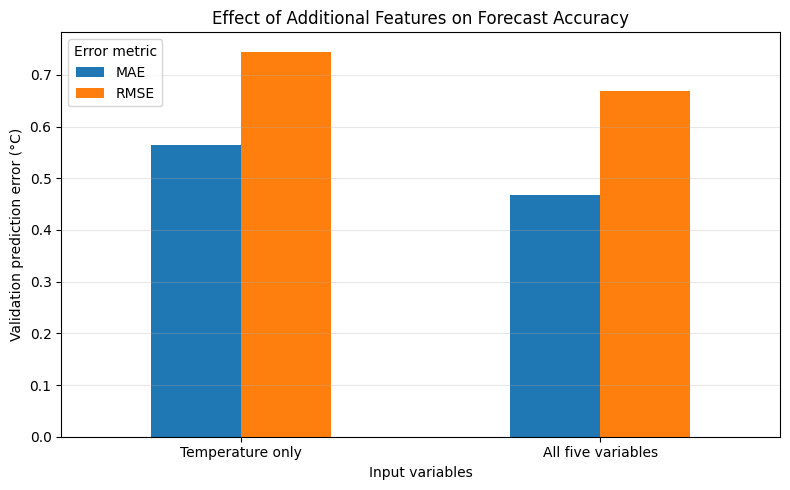

Feature ablation results saved!


In [42]:
# Save feature ablation results
ablation_results.to_csv(
    results_folder + "/feature_ablation_results.csv",
    index=False
)

# Create comparison graph
ax = ablation_results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 5),
    rot=0
)

ax.set_title("Effect of Additional Features on Forecast Accuracy")
ax.set_ylabel("Validation prediction error (°C)")
ax.set_xlabel("Input variables")
ax.legend(title="Error metric")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    results_folder + "/feature_ablation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature ablation results saved!")

In [43]:
import joblib
import os

# Create a folder for saved models
models_folder = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project/models"
)

os.makedirs(models_folder, exist_ok=True)

# Save the final trained decision tree
model_path = models_folder + "/temperature_decision_tree.joblib"

joblib.dump(final_tree, model_path)

# Check that the saved model works
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(X_test)

assert np.allclose(
    loaded_predictions,
    final_tree.predict(X_test)
)

print("Final model saved successfully!")
print("Saved model verified!")

Final model saved successfully!
Saved model verified!


In [44]:
# Update project README

readme = """# MMA3001 Building Sensor Project

## Project Overview

This project investigates one-hour-ahead indoor temperature
forecasting using environmental sensor data.

Three forecasting methods were compared:
- Persistence baseline
- Linear regression
- Decision-tree regression

## Dataset

Environmental sensor measurements were obtained from the
provided building sensor dataset.

The final analysis uses 29,557 observations from one sensor,
with temperature forecasts approximately one hour ahead.

Input variables:
- Current temperature
- Humidity
- Carbon dioxide
- Hour of day
- Day of week

## Methodology

The dataset was divided chronologically into training,
validation and testing periods.

Decision-tree depth was optimised using validation data.
The selected model was then retrained using the combined
training and validation datasets.

The test dataset was reserved for final evaluation.

## Final Test Results

| Model | MAE (°C) | RMSE (°C) | R² |
|---|---:|---:|---:|
| Persistence | 0.468 | 0.636 | 0.955 |
| Linear regression | 0.465 | 0.631 | 0.956 |
| Decision tree | 0.386 | 0.560 | 0.965 |

The selected depth-8 decision tree achieved a 17.5%
reduction in MAE compared with persistence.

## Project Structure

- data/ - Raw datasets (excluded from GitHub)
- notebooks/ - Data investigation and modelling
- src/ - Reusable Python functions
- tests/ - Automated tests
- results/ - Evaluation results and figures
- docs/ - Generated source-code documentation
- models/ - Saved trained model

## Testing

Automated tests are implemented using pytest.

Run:

    python -m pytest tests/ -v

## Dependencies

Install the required packages using:

    pip install -r requirements.txt

## Limitations

Current temperature dominates model feature importance.
Prediction errors tend to increase at higher temperatures.
Results are based on one environmental sensor, so
performance may differ for other sensors or buildings.
"""

readme_path = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project/README.md"
)

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme)

print("README updated successfully!")

README updated successfully!


In [45]:
import os

project_folder = (
    "/content/drive/MyDrive/"
    "MMA3001_Building_Sensor_Project"
)

# Display project files and folders
for root, dirs, files in os.walk(project_folder):
    # Skip temporary Python files
    dirs[:] = [
        d for d in dirs
        if d not in ["__pycache__", ".pytest_cache"]
    ]

    level = root.replace(project_folder, "").count(os.sep)
    indent = "    " * level

    print(indent + os.path.basename(root) + "/")

    for filename in sorted(files):
        if not filename.startswith("."):
            print(indent + "    " + filename)

MMA3001_Building_Sensor_Project/
    README.md
    data/
        5EnvSensor_MayToDec2024_180kRows.csv
        5occupancySensor_MayToDec2024_9MRows.csv
        Sensor ID and Locations.xlsx
        env_clean.csv
    results/
        feature_ablation_comparison.png
        feature_ablation_results.csv
        feature_importance.csv
        feature_importance.png
        final_model_comparison.csv
        final_model_comparison.png
        final_test_predictions.csv
        prediction_error_distribution.png
        temperature_error_analysis.csv
        temperature_predictions_over_time.png
    src/
        model_utils.py
    tests/
        test_model_utils.py
    docs/
        index.html
        model_utils.html
        search.js
    models/
        temperature_decision_tree.joblib
